# MLPC 2026 — Task 3: Subtask 2 — Annotations

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

plt.rcParams['figure.dpi'] = 100

In [14]:
DATA_DIR      = Path('../data')
FEATURES_DIR  = DATA_DIR / 'audio_features'

annotations_df = pd.read_csv(DATA_DIR / 'annotations.csv')
metadata_df    = pd.read_csv(DATA_DIR / 'metadata.csv')

print(f'annotations.csv : {len(annotations_df)} rows, {annotations_df["filename"].nunique()} unique files')
print(f'metadata.csv    : {len(metadata_df)} rows')
annotations_df.head()

annotations.csv : 37419 rows, 3656 unique files
metadata.csv    : 3656 rows


,filename,annotator_id,annotation,onset,offset,is_own_recording
0,000112.wav,2190518039615423109192646528977018723001939610...,footsteps,13.060211,13.315831,False
1,000695.wav,4496809211053681637690999252976315563042618669...,door_open_close,1.508440,2.061877,False
2,000488.wav,7535443191697509271271535104115945129183028445...,microwave,4.833705,25.929958,True
3,005087.wav,4496809211053681637690999252976315563042618669...,keyboard_typing,0.337356,18.230374,False
4,005465.wav,7618427328765435143030208879017391647684958822...,running_water,5.254437,15.088430,True


In [15]:
# Load all .npz feature files
# Each file holds pre-computed features + time-aligned annotations for one recording
def load_npz(path):
    return dict(np.load(path, allow_pickle=True))

npz_files = {f.stem: load_npz(f) for f in sorted(FEATURES_DIR.glob('*.npz'))}
print(f'Loaded {len(npz_files)} NPZ files')

Loaded 3656 NPZ files


In [16]:
# Inspect the structure of one file so we know what we are working with
key     = sorted(npz_files.keys())[0]
sample  = npz_files[key]

print('File:', key)
print('Keys available:', list(sample.keys()))
print()
print('annotations shape (T, C, A):', sample['annotations'].shape)
print('  T = number of 1-second time segments')
print('  C = number of sound classes')
print('  A = number of annotators for this recording')
print()
print('class_names     :', sample['class_names'])
print('target_classes  :', sample['target_classes'])
print('is_own_recording:', sample['is_own_recording'])

File: 000001
Keys available: ['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', '

In [17]:
# Verify actual time segment duration
starts    = sample['start_time']
ends      = sample['end_time']
durations = ends - starts

print('First 5 start times:', starts[:5])
print('First 5 end times:  ', ends[:5])
print('Unique segment durations:', np.unique(durations.round(4)))
print(f'Total recording length: {ends[-1]:.1f}s  ({len(starts)} segments)')

First 5 start times: [0.  0.5 1.  1.5 2. ]
First 5 end times:   [1.  1.5 2.  2.5 3. ]
Unique segment durations: [1.]
Total recording length: 31.0s  (61 segments)


In [18]:
# 2a — Pairwise annotator agreement
# One row per (recording, annotator pair, class)
# NOTE: averages over ALL segments including mutual-silence (~98% of values are 0).
# This inflates agreement artificially — see conditional agreement cell below.
rows = []

for fname, data in npz_files.items():
    ann         = data['annotations']   # [T, C, A]
    A           = ann.shape[2]
    class_names = data['class_names']

    for i, j in combinations(range(A), 2):
        #since there are values inside (0, 1) I use the difference
        #bigger the difference, smaller the agreements
        agree_per_class = 1 - np.abs(ann[:, :, i] - ann[:, :, j]).mean(axis=0)  # [C]
        for c, cls in enumerate(class_names):
            rows.append({
                'filename'  : fname,
                'class'     : cls,
                'agreement' : agree_per_class[c],
            })

agreement_df = pd.DataFrame(rows)
print(f'Total rows: {len(agreement_df)}')
agreement_df.head(16)

Total rows: 86025


,filename,class,agreement
0,000001,bell_ringing,1.000000
1,000001,coffee_machine,1.000000
2,000001,cutlery_dishes,1.000000
3,000001,door_open_close,1.000000
4,000001,footsteps,1.000000
5,000001,keyboard_typing,0.835541
6,000001,keychain,1.000000
7,000001,light_switch,1.000000
8,000001,microwave,1.000000
9,000001,phone_ringing,0.934639


In [19]:
sample_ann = npz_files['000001']['annotations']
print('Unique values:', np.unique(sample_ann))

Unique values: [0.         0.11946398 0.13746502 0.3093095  0.344      0.34699386
 0.35761318 0.35867667 0.37469462 0.3762469  0.3805103  0.3808066
 0.4130864  0.4864033  0.5093004  0.5909183  0.619464   0.637465
 0.8093095  0.844      0.84699386 0.85761315 0.8586767  0.87469465
 0.8762469  0.8805103  0.88080657 0.90813166 0.9130864  0.9311934
 0.9864033  1.        ]


In [20]:
sample_ann = npz_files['000009']['annotations']
total = sample_ann.size
print(f'Total values   : {total}')
print(f'Exactly 0.0    : {(sample_ann == 0).sum()}')
print(f'Exactly 1.0    : {(sample_ann == 1).sum()}')
print(f'Fractional     : {((sample_ann > 0) & (sample_ann < 1)).sum()}')

Total values   : 2310
Exactly 0.0    : 2284
Exactly 1.0    : 5
Fractional     : 21


In [35]:
sample = npz_files['000015']['annotations']  # [T, C, A]
# sum across classes for annotator 0, all segments
class_sums = sample[:, :, 0].sum(axis=1)  # [T]
print(class_sums)


[0.         0.         0.         0.48125145 1.086197   1.6049455
 2.         2.         1.5502989  1.0502989  1.         0.5432645
 0.08042957 0.4868366  0.707898   0.80149096 1.         1.
 1.         1.1401175  1.6401175  1.6063652  1.1063653  1.
 0.729154   0.44825184 0.71909785 1.         1.         1.
 1.         1.         0.65630263 0.28597295 0.6296703  1.
 1.104249   1.604249   2.         2.         2.         1.6027436
 0.7247798  0.3573751  0.735339   1.         1.         1.
 1.         1.         1.         0.95145583 0.45145583 0.        ]


Conditional rows: 16914  (vs 86025 naive)
class
footsteps                     0.6541
wardrobe_drawer_open_close    0.6618
door_open_close               0.6714
window_open_close             0.7062
cutlery_dishes                0.7237
keychain                      0.7357
toilet_flushing               0.7594
bell_ringing                  0.7621
light_switch                  0.7734
microwave                     0.7891
coffee_machine                0.7973
phone_ringing                 0.7980
keyboard_typing               0.8326
running_water                 0.8431
vacuum_cleaner                0.8772

Overall conditional mean: 0.7405


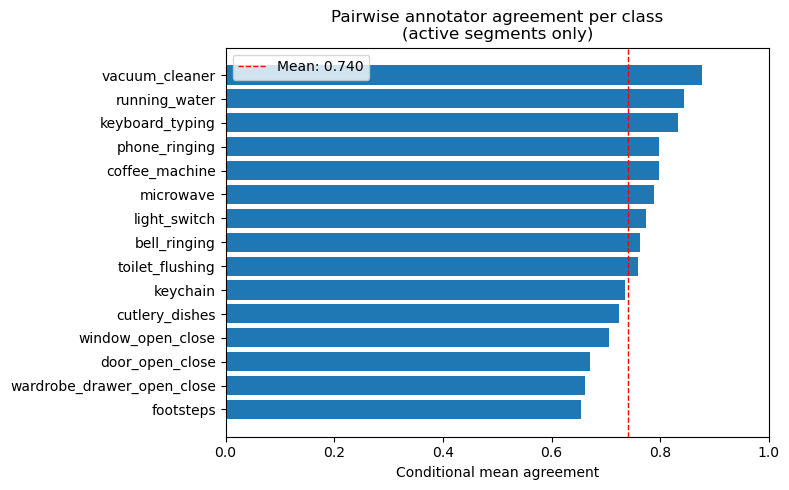

In [21]:
# 2a (revised) — Conditional pairwise agreement
# Only consider segments where at least one annotator says > 0.
# Excludes trivial mutual-silence cases that dominate the naive metric above.
rows_cond = []

for fname, data in npz_files.items():
    ann         = data['annotations']   # [T, C, A]
    A           = ann.shape[2]
    class_names = data['class_names']

    for i, j in combinations(range(A), 2):
        for c, cls in enumerate(class_names):
            a_i  = ann[:, c, i]
            a_j  = ann[:, c, j]
            mask = (a_i > 0) | (a_j > 0)   # at least one annotator active
            if mask.sum() == 0:
                continue                     # both annotators marked this class absent for all segments — nothing to compare
            agree = 1 - np.abs(a_i[mask] - a_j[mask]).mean()
            rows_cond.append({
                'filename'  : fname,
                'class'     : cls,
                'agreement' : agree,
            })

cond_agreement_df = pd.DataFrame(rows_cond)
print(f'Conditional rows: {len(cond_agreement_df)}  (vs {len(agreement_df)} naive)')

class_cond_agreement = (cond_agreement_df
                        .groupby('class')['agreement']
                        .mean()
                        .sort_values())

print(class_cond_agreement.round(4).to_string())
print(f'\nOverall conditional mean: {cond_agreement_df["agreement"].mean():.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(class_cond_agreement.index, class_cond_agreement.values)
ax.axvline(cond_agreement_df['agreement'].mean(), color='red', linestyle='--', linewidth=1,
           label=f'Mean: {cond_agreement_df["agreement"].mean():.3f}')
ax.set_xlabel('Conditional mean agreement')
ax.set_title('Pairwise annotator agreement per class\n(active segments only)')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# Annotator count distribution and owner fraction analysis
annotator_counts = {fname: data['annotations'].shape[2] for fname, data in npz_files.items()}
max_A    = max(annotator_counts.values())
max_file = max(annotator_counts, key=annotator_counts.get)

print(f'Max annotators: {max_A}  (recording {max_file})')
print(f'Min owner fraction (at A={max_A}): {2/max_A:.1%}')
print()

print('Distribution of annotator counts:')
counts_series = pd.Series(annotator_counts).value_counts().sort_index()
for n, c in counts_series.items():
    print(f'  A={n}: {c} recordings')
print()

# Check for recordings without an owner and compute mean owner pairs fraction
owner_fractions = []
no_owner = 0
for fname, data in npz_files.items():
    A        = data['annotations'].shape[2]
    has_owner = data['is_own_recording'].any()
    if has_owner:
        owner_fractions.append(2 / A)
    else:
        no_owner += 1
        owner_fractions.append(0.0)

print(f'Recordings without an owner annotator: {no_owner}')
print(f'Mean owner pairs fraction across all recordings: {np.mean(owner_fractions):.1%}')

Max annotators: 5  (recording 000015)
Min owner fraction (at A=5): 40.0%

Distribution of annotator counts:
  A=1: 625 recordings
  A=2: 1750 recordings
  A=3: 1235 recordings
  A=4: 45 recordings
  A=5: 1 recordings

Recordings without an owner annotator: 447
Mean owner pairs fraction across all recordings: 85.7%


## 2b — Convert Annotations to Labels

**Goal:** collapse `[T, C, A]` annotations into a binary `[T, C]` label matrix per recording.

### Aggregation: owner-weighted mean
Owner annotator (`is_own_recording=True`) gets weight **2**, others get weight **1**.  
Assumption: the collector of the recording knows its contents better than external annotators.

The aggregated value for a segment is:

$$\text{agg}(t,c) = \frac{2 \cdot a_{own}(t,c) + \sum_{k \neq own} a_k(t,c)}{2 + (A - 1)}$$

Weight=2 was chosen as a conservative boost — "owner counts double" rather than "owner is always right."  
In the most common case (A=2, 1750 recordings), the owner holds $\frac{2}{2+1} = \frac{2}{3} \approx 66.7\%$ of the vote: a strong advantage but not absolute.

Weight=2 is also the exact boundary for the second most common case (A=3, 1235 recordings):

$$\frac{w}{w + 2} = 0.5 \implies w = 2$$

With three annotators the owner is placed exactly at the threshold — a single disagreeing external annotator is not enough to override them, but two external annotators disagreeing together are, since their combined opinion is more reliable than one person's alone.

For $A \geq 4$, a sufficient majority of external annotators can outvote the owner, since:

$$\frac{2}{2 + (A-1)} = \frac{2}{A+1} < 0.5 \iff A > 3$$

At the maximum observed $A=5$, the owner's share drops to $\frac{2}{6} \approx 33\%$ — three external annotators agreeing are enough to override them.  
Making the owner infallible would require weight $\geq A - 1$, which at $A=5$ means weight $\geq 4$, rendering all other annotations irrelevant.

### Binarization: threshold at 0.5
A segment is labeled 1 if weighted mean overlap $\geq 0.5$ (sound covers majority of the window).

### On metadata (target_classes) — considered, not used as a hard correction
target_classes could in principle help detect:
- **FP risk**: a class gets labeled 1 but is absent from target_classes → possible mis-annotation
- **FN risk**: a target class ends up with zero labeled segments → annotators may have missed it

We chose not to apply metadata-based corrections because:
1. The owner's weight already makes corrections largely redundant. The owner appears in $(A-1)$ out of $\frac{A(A-1)}{2}$ total pairs, giving a participation fraction of $\frac{2}{A}$. Averaged across all recordings (accounting for the 447 recordings without an owner), the mean owner participation fraction is **85.7%** — meaning the owner's opinion directly shapes the majority of pairwise comparisons in a typical recording. Even at the worst case of $A=5$, this fraction is $\frac{2}{5} = 40\%$.
2. For FN: we cannot invent time marks — any automatic correction would be unjustified.
3. If the owner mislabelled their own metadata (wrong target_classes vs. what they actually annotated), a metadata correction would silently propagate that error.

### Conditions under which labels could be incorrect

**Owner reliability assumption fails**
- Owner is biased toward marking their target classes even when the sound is faint → labels become over-confident
- Owner misses sounds they didn't intend to record → false negatives for incidental sounds
- Owner made errors in their own annotation, inconsistent with their metadata

**No owner present (447 recordings)**
- All annotators get equal weight=1 — the reliability advantage disappears, labels reduce to a plain mean

**Single annotator (625 recordings, A=1)**
- No consensus possible — label entirely depends on one person's accuracy with no correction mechanism

**Owner outvoted at A≥4**
- If all external annotators disagree with the owner but the owner was correct (e.g. a subtle sound only the collector noticed), the label will be wrong

**Threshold edge cases**
- A sound event starting or ending mid-window may only partially overlap, pushing the aggregated value just below 0.5 — the sound is present but labeled absent
- Very short sounds (< 0.5s) may not reach the threshold in any window

**Ambiguous sound classes**
- Some classes sound similar (e.g. keychain vs. cutlery, footsteps vs. door) — annotators may label the same event under different classes, splitting votes and potentially thresholding both to 0

In [ ]:
# 2b — Derive binary labels from annotations
# labels[fname] is a [T, C] int8 array: 1 = class present, 0 = absent
labels = {}

for fname, data in npz_files.items():
    ann     = data['annotations']       # [T, C, A]
    is_own  = data['is_own_recording']  # [A] boolean

    # owner gets weight 2, others weight 1
    weights    = np.where(is_own, 2.0, 1.0)              # [A]
    # multiplying the annotation values (last axis)
    aggregated = (ann * weights).sum(axis=2) / weights.sum()  # [T, C]

    # binarize at 0.5
    labels[fname] = (aggregated >= 0.5).astype(np.int8)  # [T, C]

# Sanity check on first recording
print('Labels shape for 000001:', labels['000001'].shape)
print('Labeled segments per class:')
cls_names = npz_files['000001']['class_names']
for c, cls in enumerate(cls_names):
    n = labels['000001'][:, c].sum()
    if n > 0:
        print(f'  {cls}: {n} segments')

Labels shape for 000001: (61, 15)
Labeled segments per class:
  keyboard_typing: 61 segments
  phone_ringing: 15 segments


In [25]:
# 2b — Sanity check: every target class should have at least one positive label
class_names = npz_files[next(iter(npz_files))]['class_names'].tolist()

flagged = []
for fname, data in npz_files.items():
    target = list(data['target_classes'])
    for cls in target:
        c = class_names.index(cls)
        if labels[fname][:, c].sum() == 0:
            flagged.append({'filename': fname, 'class': cls})

flagged_df = pd.DataFrame(flagged)
total_target_pairs = sum(len(data['target_classes']) for data in npz_files.values())

print(f'Total (recording, target_class) pairs : {total_target_pairs}')
print(f'Flagged (zero positive labels)        : {len(flagged_df)}  ({100*len(flagged_df)/total_target_pairs:.1f}%)')
if len(flagged_df):
    print('\nFlagged breakdown by class:')
    print(flagged_df['class'].value_counts().to_string())

Total (recording, target_class) pairs : 10214
Flagged (zero positive labels)        : 967  (9.5%)

Flagged breakdown by class:
class
light_switch                  485
footsteps                     109
door_open_close                85
wardrobe_drawer_open_close     50
cutlery_dishes                 46
phone_ringing                  39
running_water                  31
keychain                       23
window_open_close              23
bell_ringing                   20
keyboard_typing                18
microwave                      12
vacuum_cleaner                 10
coffee_machine                  9
toilet_flushing                 7


In [27]:
ls_total = sum(1 for data in npz_files.values() if 'light_switch' in list(data['target_classes']))
print(f'light_switch target recordings: {ls_total}')
print(f'flagged: 485 ({100*485/ls_total:.1f}%)')


light_switch target recordings: 739
flagged: 485 (65.6%)


In [26]:
# Investigate light_switch flags — check max annotation value across all segments
# Hypothesis: short transient sounds never reach 0.5 in any window
ls_idx = class_names.index('light_switch')
ls_flagged = flagged_df[flagged_df['class'] == 'light_switch']['filename'].tolist()

max_vals = []
for fname in ls_flagged:
    ann = npz_files[fname]['annotations']   # [T, C, A]
    # max annotation value any annotator gave to light_switch in any segment
    max_vals.append(ann[:, ls_idx, :].max())

max_vals = np.array(max_vals)
print(f'Flagged light_switch recordings: {len(max_vals)}')
print(f'Max annotation value across all flagged recordings:')
print(f'  mean  : {max_vals.mean():.4f}')
print(f'  median: {np.median(max_vals):.4f}')
print(f'  max   : {max_vals.max():.4f}')
print(f'  > 0   : {(max_vals > 0).sum()}  (at least one annotator noticed it)')
print(f'  = 0   : {(max_vals == 0).sum()}  (no annotator marked anything)')
print()
print('Distribution of max values:')
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.01]
labels_bins = ['0', '(0, 0.1]', '(0.1, 0.2]', '(0.2, 0.3]', '(0.3, 0.4]', '(0.4, 0.5]']
counts, _ = np.histogram(max_vals, bins=bins)
for label, count in zip(labels_bins, counts):
    print(f'  {label:>12} : {count}')

Flagged light_switch recordings: 485
Max annotation value across all flagged recordings:
  mean  : 0.4617
  median: 0.4391
  max   : 1.0000
  > 0   : 464  (at least one annotator noticed it)
  = 0   : 21  (no annotator marked anything)

Distribution of max values:
             0 : 24
      (0, 0.1] : 16
    (0.1, 0.2] : 58
    (0.2, 0.3] : 105
    (0.3, 0.4] : 101
    (0.4, 0.5] : 181


In [28]:
# Check temporal misalignment vs low values for flagged light_switch recordings
# For each flagged recording with at least one annotator noticing it,
# check whether annotators peak in the same segment or different segments

ls_idx = class_names.index('light_switch')
same_segment  = 0
diff_segment  = 0
all_zero_anns = 0

for fname in ls_flagged:
    ann = npz_files[fname]['annotations'][:, ls_idx, :]  # [T, A]
    if ann.max() == 0:
        all_zero_anns += 1
        continue

    # find peak segment per annotator (only for annotators who gave > 0)
    active_annotators = [a for a in range(ann.shape[1]) if ann[:, a].max() > 0]
    if len(active_annotators) < 2:
        continue  # can't compare if only one annotator noticed it

    peaks = [ann[:, a].argmax() for a in active_annotators]
    if len(set(peaks)) == 1:
        same_segment += 1
    else:
        diff_segment += 1

total_comparable = same_segment + diff_segment
print(f'Flagged light_switch recordings with ≥2 annotators noticing it: {total_comparable}')
print(f'  Peak in same segment  : {same_segment}  ({100*same_segment/total_comparable:.1f}%)')
print(f'  Peak in diff segment  : {diff_segment}  ({100*diff_segment/total_comparable:.1f}%)')
print(f'  Only 1 annotator noticed (not comparable): {len(ls_flagged) - total_comparable - all_zero_anns}')
print(f'  No annotator noticed  : {all_zero_anns}')

Flagged light_switch recordings with ≥2 annotators noticing it: 363
  Peak in same segment  : 205  (56.5%)
  Peak in diff segment  : 158  (43.5%)
  Only 1 annotator noticed (not comparable): 101
  No annotator noticed  : 21


In [30]:
# Explore light_switch segment occupation for flagged recordings
# For each active annotator: how many segments did they mark > 0, and what values did they give?

ls_idx = class_names.index('light_switch')

spans_all  = []   # (n_segments, mean_value) for all active annotators
spans_diff = []   # same but only for diff-peak recordings

for fname in ls_flagged:
    ann = npz_files[fname]['annotations'][:, ls_idx, :]  # [T, A]

    active_annotators = [a for a in range(ann.shape[1]) if ann[:, a].max() > 0]
    if len(active_annotators) < 2:
        continue

    peaks = [ann[:, a].argmax() for a in active_annotators]
    is_diff = len(set(peaks)) > 1

    for a in active_annotators:
        active_segs = ann[:, a] > 0
        n_segs      = active_segs.sum()
        mean_val    = ann[active_segs, a].mean() if n_segs > 0 else 0
        spans_all.append((n_segs, mean_val))
        if is_diff:
            spans_diff.append((n_segs, mean_val))

spans_all  = np.array(spans_all)
spans_diff = np.array(spans_diff)

for label, arr in [('All flagged (≥2 annotators noticed)', spans_all),
                   ('Diff-peak subset',                    spans_diff)]:
    print(f'--- {label} ---')
    print(f'  Annotator observations : {len(arr)}')
    print(f'  Segments marked (span):')
    print(f'    mean   : {arr[:,0].mean():.2f}')
    print(f'    median : {np.median(arr[:,0]):.1f}')
    print(f'    distribution:')
    for n in sorted(np.unique(arr[:,0]).astype(int)):
        count = (arr[:,0] == n).sum()
        print(f'      {n} segment(s): {count}  ({100*count/len(arr):.1f}%)')
    print(f'  Mean value in marked segments:')
    print(f'    mean   : {arr[:,1].mean():.4f}')
    print(f'    median : {np.median(arr[:,1]):.4f}')
    print()

--- All flagged (≥2 annotators noticed) ---
  Annotator observations : 868
  Segments marked (span):
    mean   : 3.69
    median : 3.0
    distribution:
      1 segment(s): 11  (1.3%)
      2 segment(s): 210  (24.2%)
      3 segment(s): 389  (44.8%)
      4 segment(s): 68  (7.8%)
      5 segment(s): 76  (8.8%)
      6 segment(s): 62  (7.1%)
      7 segment(s): 11  (1.3%)
      8 segment(s): 11  (1.3%)
      9 segment(s): 7  (0.8%)
      10 segment(s): 5  (0.6%)
      11 segment(s): 3  (0.3%)
      12 segment(s): 4  (0.5%)
      13 segment(s): 2  (0.2%)
      15 segment(s): 1  (0.1%)
      16 segment(s): 2  (0.2%)
      17 segment(s): 2  (0.2%)
      24 segment(s): 2  (0.2%)
      26 segment(s): 1  (0.1%)
      44 segment(s): 1  (0.1%)
  Mean value in marked segments:
    mean   : 0.2753
    median : 0.2570

--- Diff-peak subset ---
  Annotator observations : 394
  Segments marked (span):
    mean   : 4.55
    median : 3.0
    distribution:
      1 segment(s): 4  (1.0%)
      2 segment

In [31]:
# Check whether active segments are contiguous or fragmented
# A span is contiguous if all non-zero segments form a single unbroken block

def is_contiguous(active_mask):
    """True if all True entries in active_mask form one contiguous block."""
    indices = np.where(active_mask)[0]
    return bool(np.all(np.diff(indices) == 1))

ls_idx = class_names.index('light_switch')

results = {'all': {'contiguous': 0, 'fragmented': 0},
           'diff': {'contiguous': 0, 'fragmented': 0}}

for fname in ls_flagged:
    ann = npz_files[fname]['annotations'][:, ls_idx, :]  # [T, A]

    active_annotators = [a for a in range(ann.shape[1]) if ann[:, a].max() > 0]
    if len(active_annotators) < 2:
        continue

    peaks   = [ann[:, a].argmax() for a in active_annotators]
    is_diff = len(set(peaks)) > 1

    for a in active_annotators:
        mask = ann[:, a] > 0
        if mask.sum() < 2:      # single segment is trivially contiguous
            results['all']['contiguous'] += 1
            if is_diff:
                results['diff']['contiguous'] += 1
            continue
        key = 'contiguous' if is_contiguous(mask) else 'fragmented'
        results['all'][key] += 1
        if is_diff:
            results['diff'][key] += 1

for label, key in [('All flagged (≥2 annotators noticed)', 'all'),
                   ('Diff-peak subset',                    'diff')]:
    c = results[key]['contiguous']
    f = results[key]['fragmented']
    total = c + f
    print(f'--- {label} ---')
    print(f'  Contiguous : {c}  ({100*c/total:.1f}%)')
    print(f'  Fragmented : {f}  ({100*f/total:.1f}%)')
    print()

--- All flagged (≥2 annotators noticed) ---
  Contiguous : 694  (80.0%)
  Fragmented : 174  (20.0%)

--- Diff-peak subset ---
  Contiguous : 263  (66.8%)
  Fragmented : 131  (33.2%)



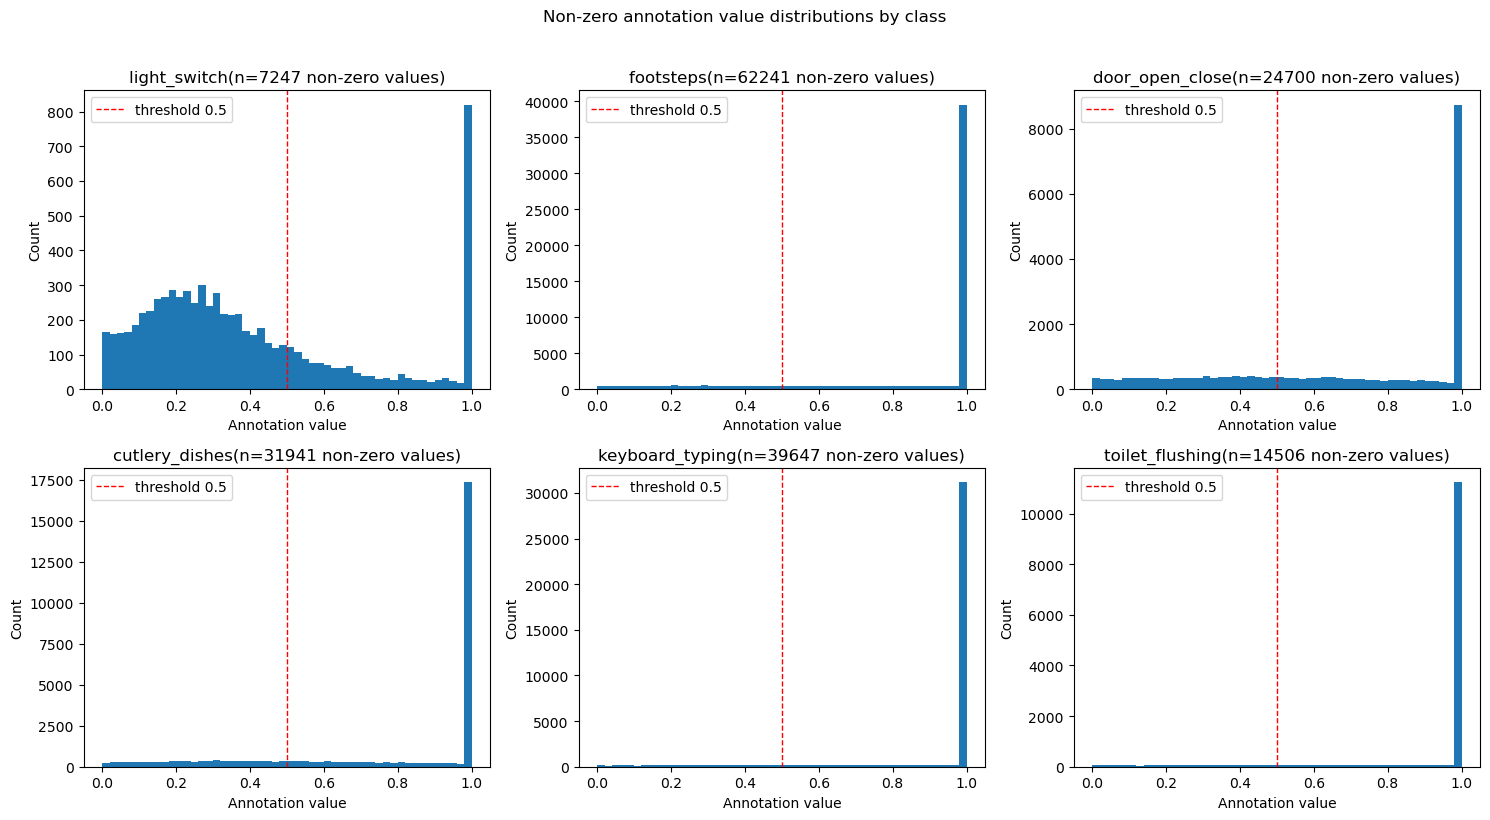

In [39]:
# Distribution of non-zero annotation values for selected classes
# Comparing problematic (light_switch, footsteps, door_open_close, cutlery_dishes)
# vs clean (keyboard_typing, toilet_flushing)

selected_classes = ['light_switch', 'footsteps', 'door_open_close', 'cutlery_dishes',
                    'keyboard_typing', 'toilet_flushing']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, cls in zip(axes, selected_classes):
    cls_idx = class_names.index(cls)
    vals = []
    for data in npz_files.values():
        ann = data["annotations"][:, cls_idx, :]  # [T, A]
        nonzero = ann[ann > 0]
        vals.extend(nonzero.tolist())

    vals = np.array(vals)
    ax.hist(vals, bins=50, range=(0, 1), edgecolor="none")
    ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="threshold 0.5")
    ax.set_title(f"{cls}(n={len(vals)} non-zero values)")
    ax.set_xlabel("Annotation value")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Non-zero annotation value distributions by class", y=1.02)
plt.tight_layout()
plt.show()


In [40]:
# Check whether light_switch flags correlate with owner being the one who noticed it
# Hypothesis: flags occur when the non-owner annotator noticed it but owner did not

ls_idx = class_names.index("light_switch")

owner_noticed    = 0  # owner gave > 0, all non-owners gave 0
nonowner_noticed = 0  # at least one non-owner gave > 0, owner gave 0
both_noticed     = 0  # both owner and at least one non-owner gave > 0
no_owner         = 0  # recording has no owner annotator
neither          = 0  # no annotator gave > 0

for fname in ls_flagged:
    data    = npz_files[fname]
    ann     = data["annotations"][:, ls_idx, :]  # [T, A]
    is_own  = data["is_own_recording"]            # [A]

    owner_idx    = np.where(is_own)[0]
    nonowner_idx = np.where(~is_own)[0]

    if len(owner_idx) == 0:
        no_owner += 1
        continue

    owner_max    = ann[:, owner_idx].max()
    nonowner_max = ann[:, nonowner_idx].max() if len(nonowner_idx) > 0 else 0

    if owner_max == 0 and nonowner_max == 0:
        neither += 1
    elif owner_max > 0 and nonowner_max == 0:
        owner_noticed += 1
    elif owner_max == 0 and nonowner_max > 0:
        nonowner_noticed += 1
    else:
        both_noticed += 1

total = len(ls_flagged)
print(f"Flagged light_switch recordings: {total}")
print(f"  Owner noticed, non-owner did not : {owner_noticed}  ({100*owner_noticed/total:.1f}%)")
print(f"  Non-owner noticed, owner did not : {nonowner_noticed}  ({100*nonowner_noticed/total:.1f}%)")
print(f"  Both noticed (still flagged)     : {both_noticed}  ({100*both_noticed/total:.1f}%)")
print(f"  No owner annotator               : {no_owner}  ({100*no_owner/total:.1f}%)")
print(f"  Neither noticed                  : {neither}  ({100*neither/total:.1f}%)")


Flagged light_switch recordings: 485
  Owner noticed, non-owner did not : 65  (13.4%)
  Non-owner noticed, owner did not : 14  (2.9%)
  Both noticed (still flagged)     : 344  (70.9%)
  No owner annotator               : 46  (9.5%)
  Neither noticed                  : 16  (3.3%)


In [42]:
# Check flagged footsteps: owner/non-owner breakdown + annotator count distribution

fs_idx      = class_names.index("footsteps")
fs_flagged  = flagged_df[flagged_df["class"] == "footsteps"]["filename"].tolist()
fs_total    = sum(1 for data in npz_files.values() if "footsteps" in list(data["target_classes"]))

owner_noticed    = 0
nonowner_noticed = 0
both_noticed     = 0
no_owner         = 0
neither          = 0
annotator_counts = []

for fname in fs_flagged:
    data   = npz_files[fname]
    ann    = data["annotations"][:, fs_idx, :]  # [T, A]
    is_own = data["is_own_recording"]            # [A]
    A      = ann.shape[1]
    annotator_counts.append(A)

    owner_idx    = np.where(is_own)[0]
    nonowner_idx = np.where(~is_own)[0]

    if len(owner_idx) == 0:
        no_owner += 1
        continue

    owner_max    = ann[:, owner_idx].max()
    nonowner_max = ann[:, nonowner_idx].max() if len(nonowner_idx) > 0 else 0

    if owner_max == 0 and nonowner_max == 0:
        neither += 1
    elif owner_max > 0 and nonowner_max == 0:
        owner_noticed += 1
    elif owner_max == 0 and nonowner_max > 0:
        nonowner_noticed += 1
    else:
        both_noticed += 1

flagged = len(fs_flagged)
print(f"Footsteps total target recordings : {fs_total}")
print(f"Flagged (zero positive labels)    : {flagged}  ({100*flagged/fs_total:.1f}%)")
print()
print(f"Breakdown of flagged ({flagged}):")
print(f"  Owner noticed, non-owner did not : {owner_noticed}  ({100*owner_noticed/flagged:.1f}% of flagged, {100*owner_noticed/fs_total:.1f}% of total)")
print(f"  Non-owner noticed, owner did not : {nonowner_noticed}  ({100*nonowner_noticed/flagged:.1f}% of flagged, {100*nonowner_noticed/fs_total:.1f}% of total)")
print(f"  Both noticed (still flagged)     : {both_noticed}  ({100*both_noticed/flagged:.1f}% of flagged, {100*both_noticed/fs_total:.1f}% of total)")
print(f"  No owner annotator               : {no_owner}  ({100*no_owner/flagged:.1f}% of flagged, {100*no_owner/fs_total:.1f}% of total)")
print(f"  Neither noticed                  : {neither}  ({100*neither/flagged:.1f}% of flagged, {100*neither/fs_total:.1f}% of total)")
print()
print("Annotator count distribution (flagged only):")
counts = pd.Series(annotator_counts).value_counts().sort_index()
for n, c in counts.items():
    print(f"  A={n}: {c}  ({100*c/flagged:.1f}%)")


Footsteps total target recordings : 1720
Flagged (zero positive labels)    : 109  (6.3%)

Breakdown of flagged (109):
  Owner noticed, non-owner did not : 11  (10.1% of flagged, 0.6% of total)
  Non-owner noticed, owner did not : 35  (32.1% of flagged, 2.0% of total)
  Both noticed (still flagged)     : 6  (5.5% of flagged, 0.3% of total)
  No owner annotator               : 11  (10.1% of flagged, 0.6% of total)
  Neither noticed                  : 46  (42.2% of flagged, 2.7% of total)

Annotator count distribution (flagged only):
  A=1: 20  (18.3%)
  A=2: 59  (54.1%)
  A=3: 29  (26.6%)
  A=4: 1  (0.9%)


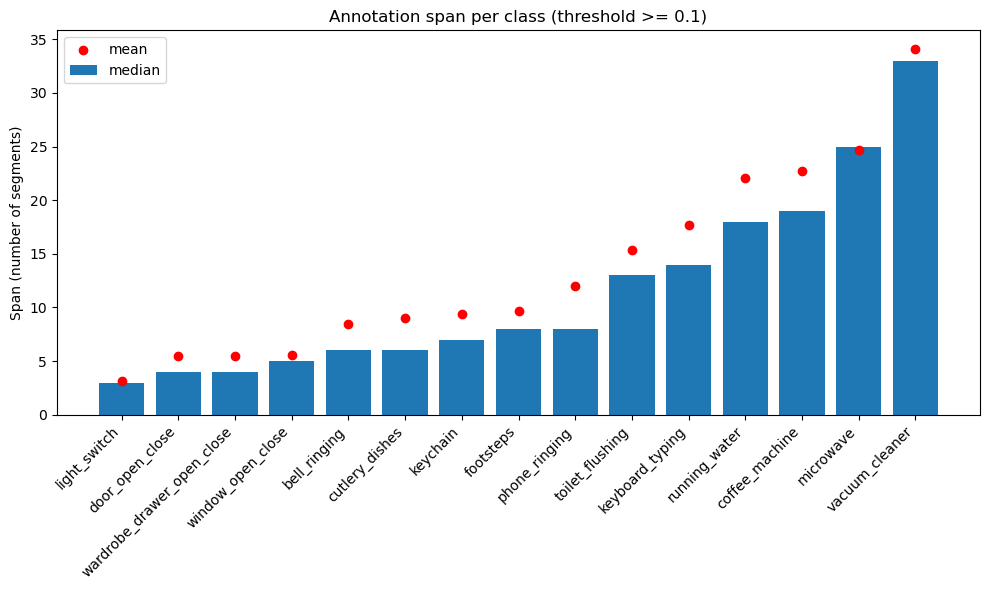

Class                            Median     Mean    N spans
light_switch                        3.0      3.1       2061
door_open_close                     4.0      5.5       4240
wardrobe_drawer_open_close          4.0      5.5       2294
window_open_close                   5.0      5.5       1460
bell_ringing                        6.0      8.5        718
cutlery_dishes                      6.0      9.1       3380
keychain                            7.0      9.4       2413
footsteps                           8.0      9.7       6202
phone_ringing                       8.0     12.0       2314
toilet_flushing                    13.0     15.4        921
keyboard_typing                    14.0     17.7       2198
running_water                      18.0     22.1       2298
coffee_machine                     19.0     22.7        646
microwave                          25.0     24.7       1158
vacuum_cleaner                     33.0     34.1        734


In [43]:
# Segment span distribution per class (all recordings, all annotators)
# For each annotator x recording x class: how many contiguous segments were marked > 0.1
# Helps identify which classes have structurally short annotations

BINARIZE_THRESH = 0.1
all_class_names = list(npz_files[next(iter(npz_files))]["class_names"])

span_data = {cls: [] for cls in all_class_names}

for data in npz_files.values():
    ann = data["annotations"]  # [T, C, A]
    for c, cls in enumerate(all_class_names):
        for a in range(ann.shape[2]):
            active = ann[:, c, a] >= BINARIZE_THRESH
            if not active.any():
                continue
            # count contiguous runs of True
            changes = np.diff(active.astype(int))
            starts  = np.where(changes == 1)[0] + 1
            ends    = np.where(changes == -1)[0] + 1
            if active[0]:  starts = np.concatenate([[0], starts])
            if active[-1]: ends   = np.concatenate([ends, [len(active)]])
            for s, e in zip(starts, ends):
                span_data[cls].append(e - s)

# Plot median span per class as bar chart, with mean overlaid
medians = {cls: np.median(v) if v else 0 for cls, v in span_data.items()}
means   = {cls: np.mean(v)   if v else 0 for cls, v in span_data.items()}
sorted_cls = sorted(medians, key=medians.get)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(sorted_cls))
ax.bar(x, [medians[c] for c in sorted_cls], label="median")
ax.scatter(x, [means[c] for c in sorted_cls], color="red", zorder=3, label="mean")
ax.set_xticks(x)
ax.set_xticklabels(sorted_cls, rotation=45, ha="right")
ax.set_ylabel("Span (number of segments)")
ax.set_title(f"Annotation span per class (threshold >= {BINARIZE_THRESH})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{"Class":<30} {"Median":>8} {"Mean":>8} {"N spans":>10}")
for cls in sorted_cls:
    v = span_data[cls]
    print(f"{cls:<30} {np.median(v):>8.1f} {np.mean(v):>8.1f} {len(v):>10}")


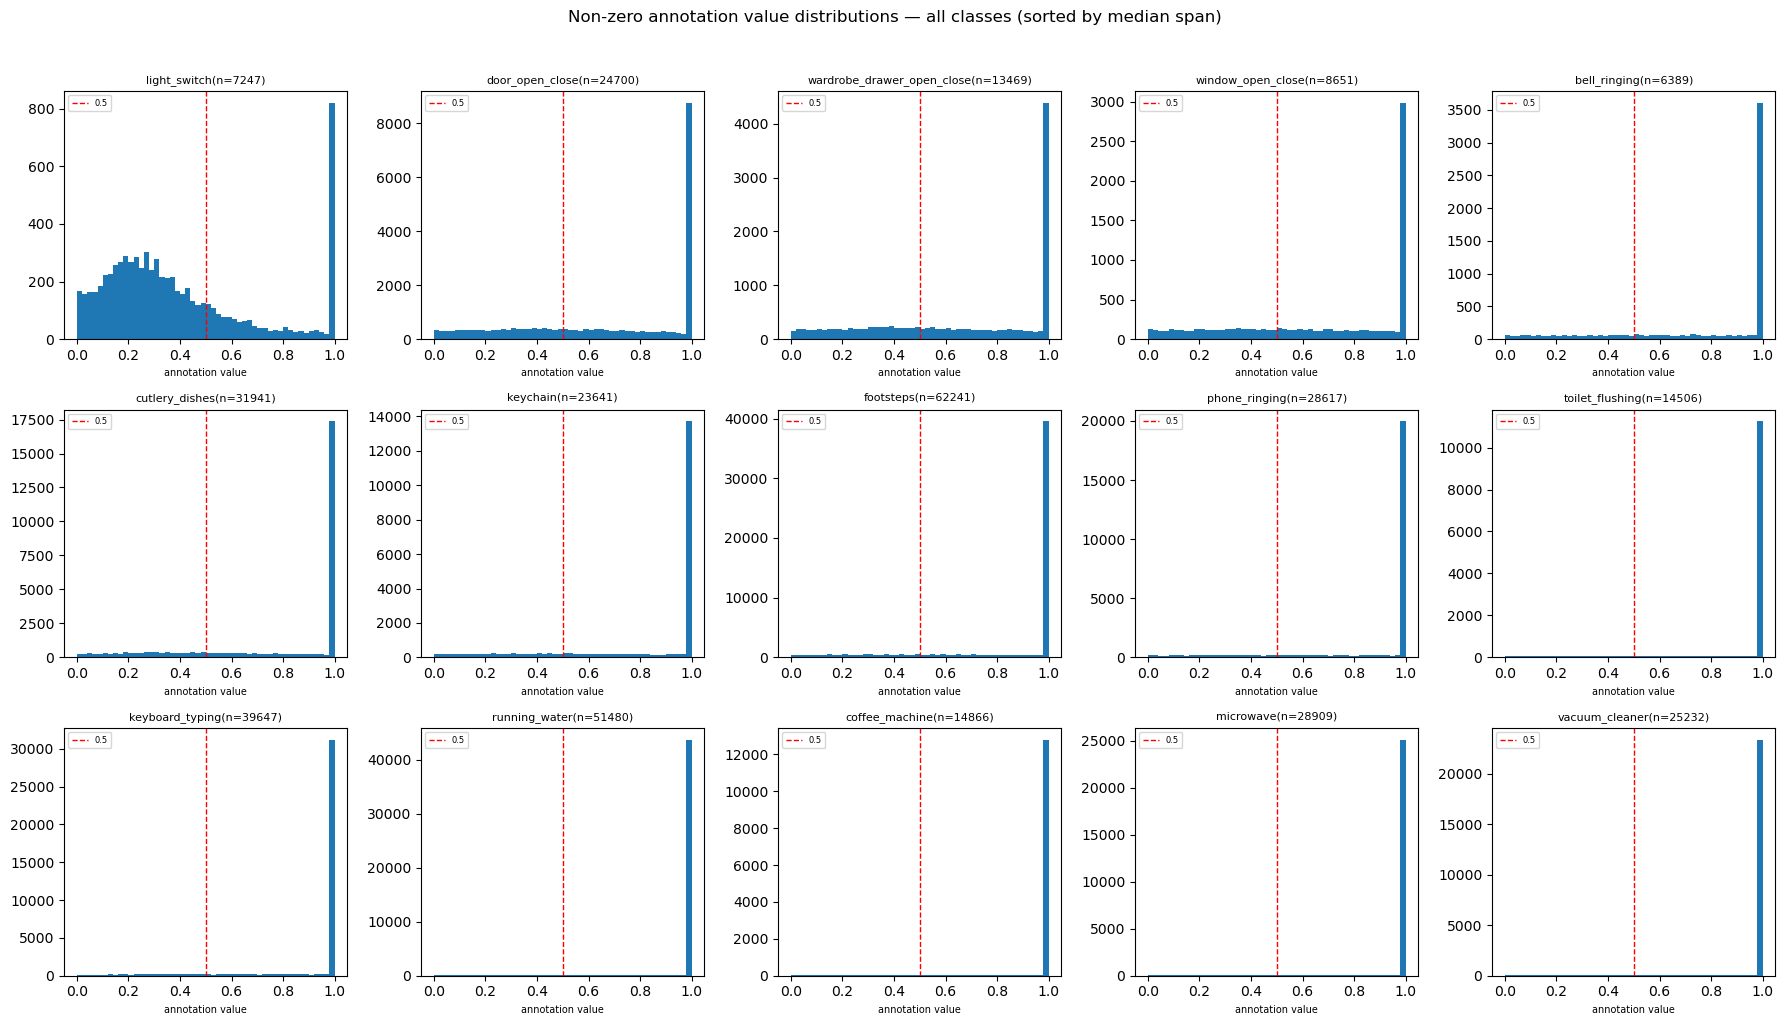

In [52]:
# Non-zero annotation value distributions for all 15 classes
# sorted by median span (shortest to longest) so transient vs sustained pattern is visible

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for ax, cls in zip(axes, sorted_cls):
    cls_idx = all_class_names.index(cls)
    vals = []
    for data in npz_files.values():
        ann = data["annotations"][:, cls_idx, :]
        vals.extend(ann[ann > 0].tolist())
    vals = np.array(vals)
    ax.hist(vals, bins=50, range=(0, 1), edgecolor="none")
    ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="0.5")
    ax.set_title(f"{cls}(n={len(vals)})", fontsize=8)
    ax.set_xlabel("annotation value", fontsize=7)
    ax.legend(fontsize=6)

plt.suptitle("Non-zero annotation value distributions — all classes (sorted by median span)", y=1.02)
plt.tight_layout()
plt.show()


In [50]:
# 2b (revised) — Binary labels using per-annotator binarization
# Fixes the systematic failure for transient classes (light_switch, door_open_close, etc.)
# where overlap fractions are structurally capped below 0.5 even with full annotator agreement.
#
# Method: binarize each annotator independently at threshold 0.1 first,
# then apply owner-weighted mean on binary votes, then threshold at 0.5.
# This separates "was the sound present?" from "how much of the window did it occupy?"
# Owner weighting (weight=2) is preserved unchanged.

ANNOTATOR_THRESH = 0.1

labels_v2 = {}

for fname, data in npz_files.items():
    ann    = data["annotations"]       # [T, C, A]
    is_own = data["is_own_recording"]   # [A]

    votes      = (ann >= ANNOTATOR_THRESH).astype(np.float32)  # [T, C, A]
    weights    = np.where(is_own, 2.0, 1.0)                    # [A]
    aggregated = (votes * weights).sum(axis=2) / weights.sum() # [T, C]

    labels_v2[fname] = (aggregated >= 0.5).astype(np.int8)     # [T, C]

# Sanity check against target_classes
flagged_v2 = []
for fname, data in npz_files.items():
    for cls in list(data["target_classes"]):
        c = all_class_names.index(cls)
        if labels_v2[fname][:, c].sum() == 0:
            flagged_v2.append({"filename": fname, "class": cls})

flagged_v2_df = pd.DataFrame(flagged_v2)
print(f"labels    (original) — flagged: {len(flagged_df):>4}  ({100*len(flagged_df)/total_target_pairs:.1f}%)")
print(f"labels_v2 (revised)  — flagged: {len(flagged_v2_df):>4}  ({100*len(flagged_v2_df)/total_target_pairs:.1f}%)")
print()
if len(flagged_v2_df):
    print("Flagged breakdown by class (v2):")
    print(flagged_v2_df["class"].value_counts().to_string())


labels    (original) — flagged:  967  (9.5%)
labels_v2 (revised)  — flagged:  366  (3.6%)

Flagged breakdown by class (v2):
class
footsteps                     89
door_open_close               40
light_switch                  36
running_water                 29
cutlery_dishes                26
phone_ringing                 25
wardrobe_drawer_open_close    20
keychain                      19
keyboard_typing               17
bell_ringing                  16
window_open_close             13
microwave                     11
vacuum_cleaner                10
coffee_machine                 8
toilet_flushing                7


In [57]:
# Categorize remaining flags in labels_v2

ANNOTATOR_THRESH = 0.1

single_annotator    = 0   # A=1, no consensus possible
no_owner            = 0   # no owner present, all weights equal
neither_noticed     = 0   # no annotator gave >= 0.1
owner_outvoted      = 0   # owner noticed but non-owners outvoted them
nonowner_outvoted   = 0   # non-owner(s) noticed but owner + others outvoted them

for row in flagged_v2_df.itertuples():
    fname  = row.filename
    cls    = row._2
    data   = npz_files[fname]
    ann    = data["annotations"][:, all_class_names.index(cls), :]  # [T, A]
    is_own = data["is_own_recording"]  # [A]
    A      = ann.shape[1]

    if A == 1:
        single_annotator += 1
        continue
    if not is_own.any():
        no_owner += 1
        continue
    if (ann >= ANNOTATOR_THRESH).sum() == 0:
        neither_noticed += 1
        continue

    # outvoted — determine who noticed it
    owner_idx    = np.where(is_own)[0]
    nonowner_idx = np.where(~is_own)[0]
    owner_noticed    = ann[:, owner_idx].max() >= ANNOTATOR_THRESH
    nonowner_noticed = len(nonowner_idx) > 0 and ann[:, nonowner_idx].max() >= ANNOTATOR_THRESH

    if owner_noticed and not nonowner_noticed:
        owner_outvoted += 1       # owner noticed, non-owners did not — owner lost to zeros
    elif nonowner_noticed and not owner_noticed:
        nonowner_outvoted += 1    # non-owner(s) noticed, owner did not
    else:
        nonowner_outvoted += 1    # both noticed but combined non-owner zeros pulled below 0.5

total     = len(flagged_v2_df)
accounted = single_annotator + no_owner + neither_noticed + owner_outvoted + nonowner_outvoted
print(f"Remaining flags in labels_v2: {total}")
print(f"  A=1 (no consensus possible)             : {single_annotator}  ({100*single_annotator/total:.1f}%)")
print(f"  No owner (equal weights)                : {no_owner}  ({100*no_owner/total:.1f}%)")
print(f"  Neither noticed (all < 0.1)             : {neither_noticed}  ({100*neither_noticed/total:.1f}%)")
print(f"  Owner noticed, outvoted by non-owners   : {owner_outvoted}  ({100*owner_outvoted/total:.1f}%)")
print(f"  Non-owner noticed, owner did not        : {nonowner_outvoted}  ({100*nonowner_outvoted/total:.1f}%)")
print(f"  Accounted for: {accounted}/{total}")

# fraction of non-owner-noticed flags vs all owner-present target pairs
owner_target_pairs = sum(
    len(data["target_classes"])
    for data in npz_files.values()
    if data["is_own_recording"].any()
)
print(f"Owner-present (recording, target_class) pairs: {owner_target_pairs}")
print(f"Non-owner noticed, owner did not: {nonowner_outvoted} ({100*nonowner_outvoted/owner_target_pairs:.2f}% of owner-present pairs)")


Remaining flags in labels_v2: 366
  A=1 (no consensus possible)             : 78  (21.3%)
  No owner (equal weights)                : 18  (4.9%)
  Neither noticed (all < 0.1)             : 164  (44.8%)
  Owner noticed, outvoted by non-owners   : 2  (0.5%)
  Non-owner noticed, owner did not        : 104  (28.4%)
  Accounted for: 366/366
Owner-present (recording, target_class) pairs: 9020
Non-owner noticed, owner did not: 104 (1.15% of owner-present pairs)
